In [1]:
# IMPORTING LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
#LOADING DATASET

In [4]:
df = pd.read_csv("diabetes new dataset.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_Level
0,1,123.854532,70.552013,47.564623,140.225349,44.067900,0.205703,40.960570,0,Obese,Mid,Prediabetes
1,1,117.297774,71.079050,41.263556,111.154260,29.703077,1.136390,33.340828,0,Overweight,Adult,Prediabetes
2,2,110.176908,100.378619,29.175547,117.197124,28.162753,1.915921,42.772262,0,Overweight,Mid,Prediabetes
3,2,116.422941,95.603386,32.177355,143.376177,31.713198,2.046737,53.276358,1,Obese,Mid,Prediabetes
4,4,97.760847,77.837421,33.367973,121.180076,29.708066,0.585468,32.190160,1,Overweight,Adult,Normal


In [5]:
# DATASET OVERVIEW

In [6]:
df.shape

(6000, 12)

In [7]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'BMI_Category',
       'Age_Group', 'Glucose_Level'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               6000 non-null   int64  
 1   Glucose                   5400 non-null   float64
 2   BloodPressure             5400 non-null   float64
 3   SkinThickness             5400 non-null   float64
 4   Insulin                   5400 non-null   float64
 5   BMI                       5400 non-null   float64
 6   DiabetesPedigreeFunction  6000 non-null   float64
 7   Age                       6000 non-null   float64
 8   Outcome                   6000 non-null   int64  
 9   BMI_Category              6000 non-null   object 
 10  Age_Group                 6000 non-null   object 
 11  Glucose_Level             6000 non-null   object 
dtypes: float64(7), int64(2), object(3)
memory usage: 562.6+ KB


In [9]:
#MISSING VALUE ANALYSIS

In [10]:
df.isnull().sum()

Pregnancies                   0
Glucose                     600
BloodPressure               600
SkinThickness               600
Insulin                     600
BMI                         600
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
BMI_Category                  0
Age_Group                     0
Glucose_Level                 0
dtype: int64

In [11]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,6000.00000,5400.000000,5400.000000,5400.000000,5400.000000,5400.000000,6000.000000,6000.000000,6000.000000
mean,2.03700,115.835214,83.825779,35.515809,135.953069,31.774559,1.298174,35.392750,0.500167
std,1.43677,11.739758,9.912827,6.837043,21.365675,5.841747,0.688374,11.161992,0.500042
min,0.00000,75.032013,50.593698,10.000000,61.840956,18.000000,0.100112,18.000000,0.000000
25%,1.00000,107.913429,77.130215,30.784689,121.719285,27.713900,0.719152,27.037625,0.000000
50%,2.00000,115.763613,83.784085,35.628496,135.844838,31.736218,1.290135,35.023442,1.000000
75%,3.00000,123.784172,90.573293,40.245514,150.184380,35.769599,1.890566,42.882272,1.000000
max,8.00000,159.083268,117.458364,59.394238,225.161865,50.000000,2.499855,80.000000,1.000000


In [12]:
# OUTLIER DETECTION USING BOXPLOTS

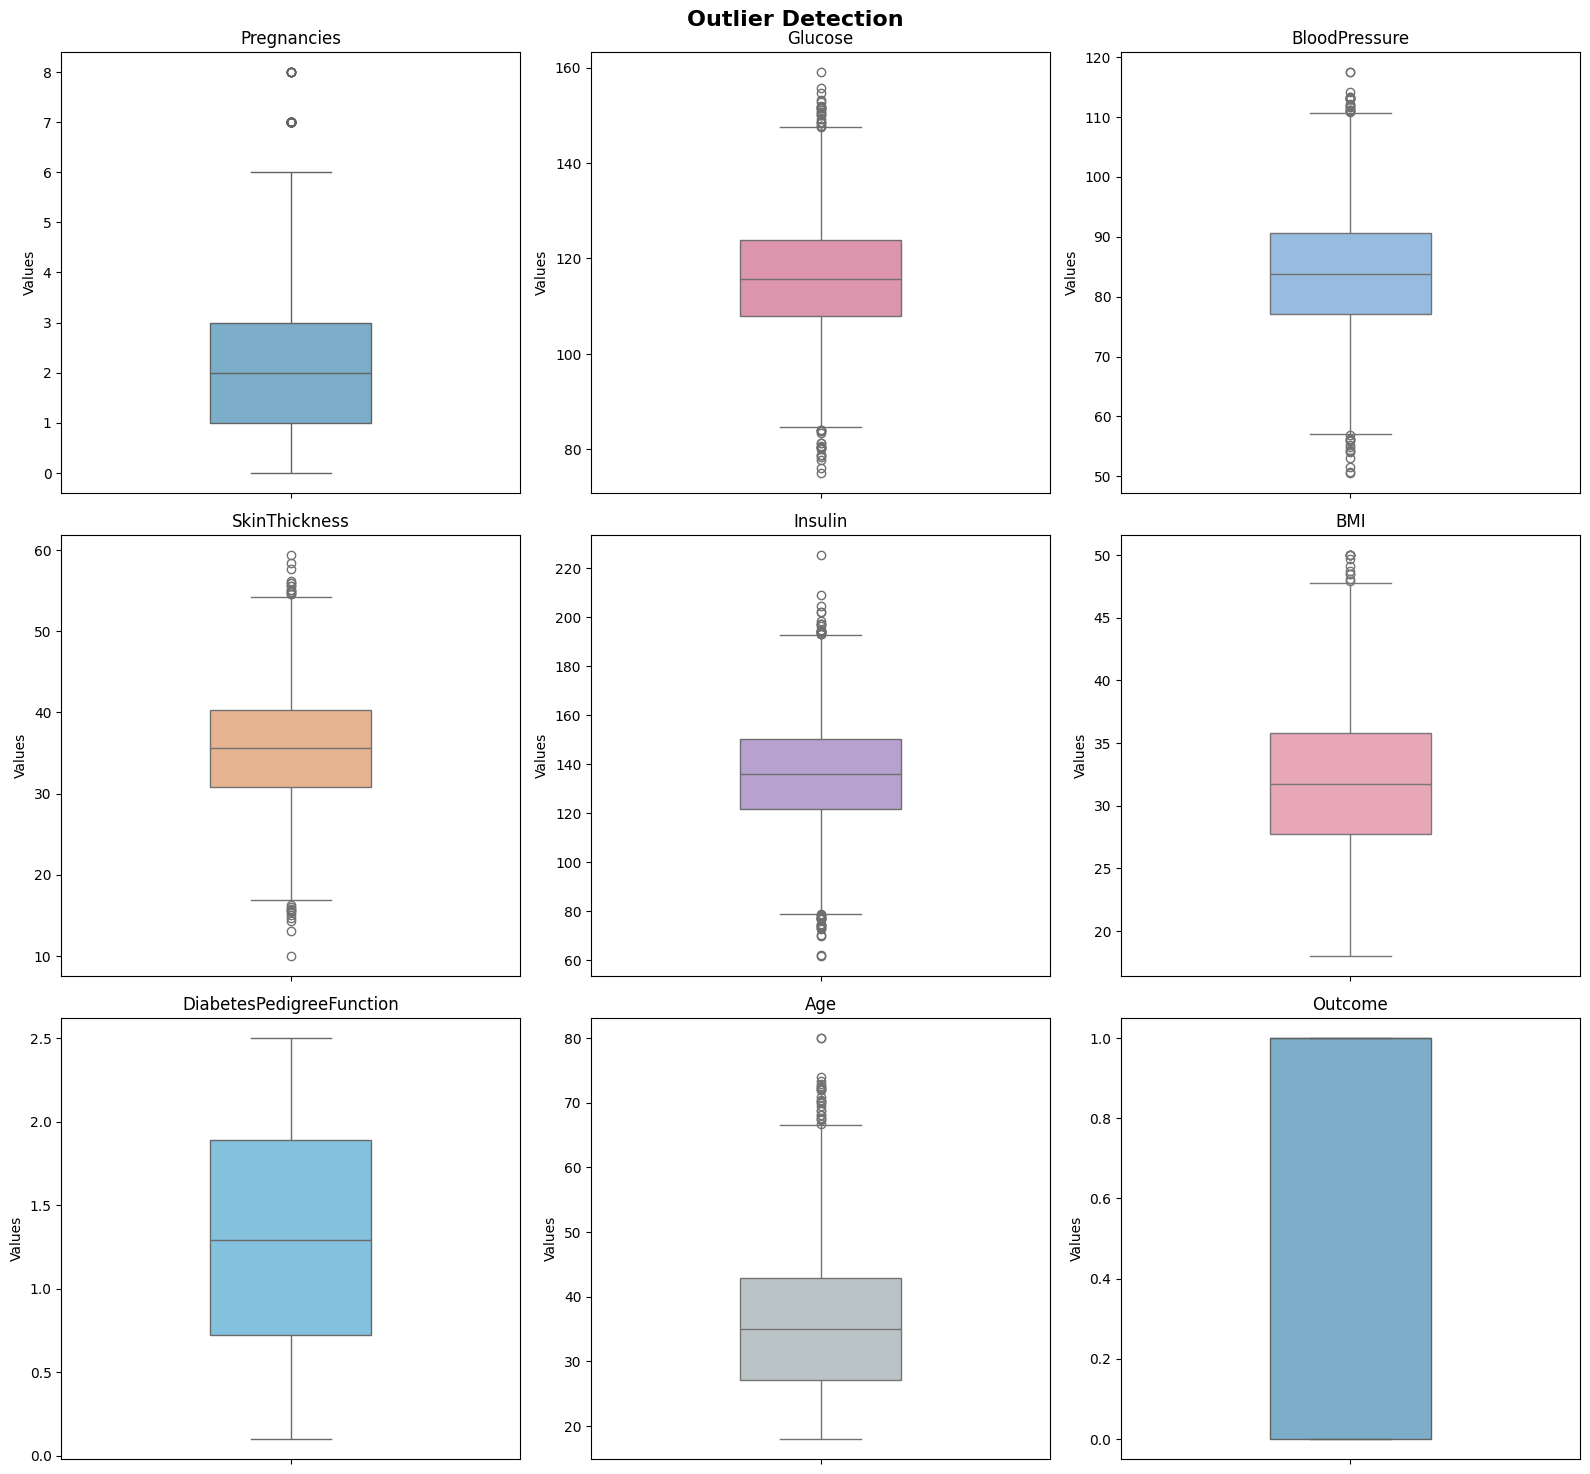

In [13]:
numeric_df = df.select_dtypes(include=['number'])
cols = numeric_df.columns
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols
fig, ax = plt.subplots(n_rows, n_cols, figsize=(16, 5*n_rows))
ax = ax.flatten()
colors = ['#6FB1D6','#E889A8','#8CBCEB','#F4B183','#B79AD6', '#F29CB2','#74C7EC','#B8C5C9']
for i, col in enumerate(cols):
    sns.boxplot(y=numeric_df[col],ax=ax[i],color=colors[i % len(colors)],width=0.35)
    ax[i].set_title(col, fontsize=12)
    ax[i].set_ylabel("Values")
for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])
plt.suptitle("Outlier Detection", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# HANDDLING MISSING VALUES USING MEDIAN 

In [15]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in cols:
    df[col] = df[col].fillna(df[col].median())
    #Rounding decimals
df['Age']=df['Age'].round().astype(int)
df['Glucose']=df['Glucose'].round(2)
df['BloodPressure']=df['BloodPressure'].round(2)
df['SkinThickness']=df['SkinThickness'].round(2)
df['Insulin']=df['Insulin'].round(2)
df['BMI']=df['BMI'].round(2)
df['DiabetesPedigreeFunction']=df['DiabetesPedigreeFunction'].round(2)

In [16]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
BMI_Category                0
Age_Group                   0
Glucose_Level               0
dtype: int64

In [17]:
# DISTRIBUTION ANALYSIS OF NUMERICAL FEATURES

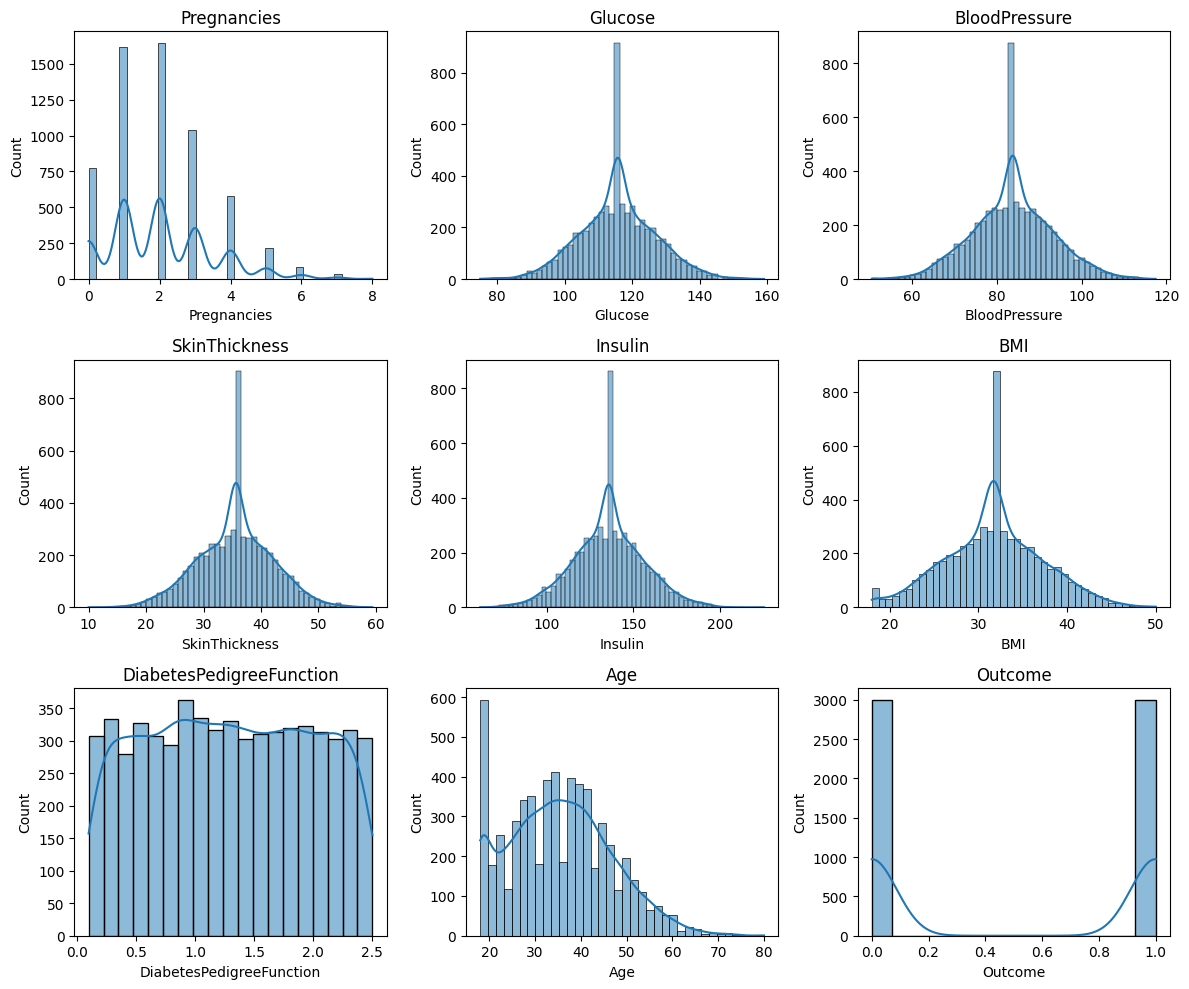

In [18]:
cols = df.select_dtypes(include=['number']).columns
fig, ax = plt.subplots(3, 3, figsize=(12,10))
ax = ax.flatten()
for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=ax[i])
    ax[i].set_title(col)
# remove extra empty plots
for j in range(i+1, len(ax)):
    fig.delaxes(ax[j])
plt.tight_layout()
plt.show()

In [19]:
# DIABETES OUTCOME DISTRIBUTION

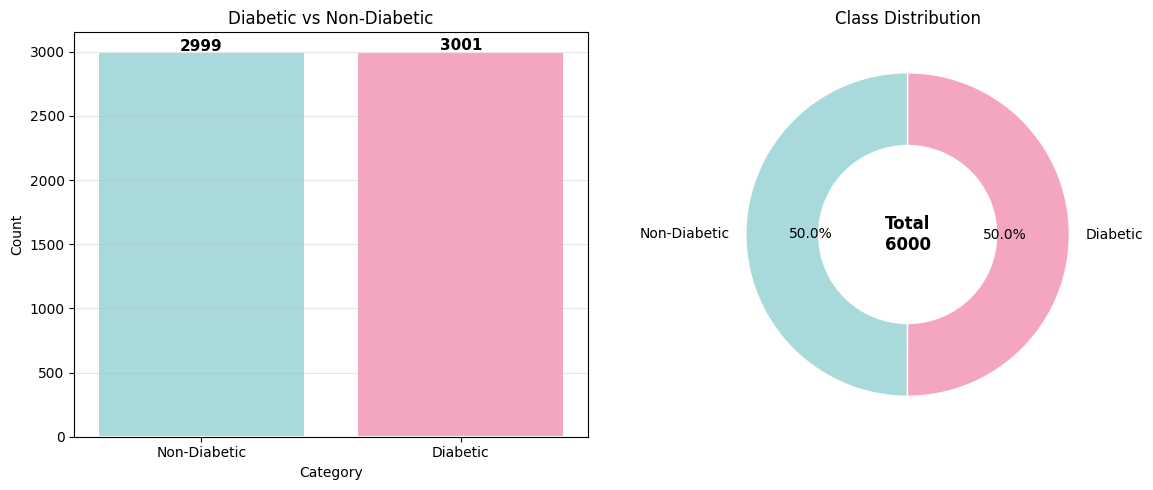

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
counts = df['Outcome'].value_counts().sort_index()
x = counts.index
y = counts.values
bars = axes[0].bar(x,y,color=['#A8DADC', '#F4A6C1'],edgecolor='white',linewidth=1.5)
axes[0].set_title('Diabetic vs Non-Diabetic')
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Count")
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['Non-Diabetic', 'Diabetic'])
# value labels
for i in range(len(x)):
    axes[0].text(x[i],y[i] + 10,y[i],ha='center',fontsize=11,fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[1].pie(y,labels=['Non-Diabetic', 'Diabetic'],colors=['#A8DADC', '#F4A6C1'],autopct='%1.1f%%',startangle=90,
    wedgeprops=dict(width=0.45, edgecolor='white'))
axes[1].set_title("Class Distribution")
# donut center text
axes[1].text(0, 0, f"Total\n{len(df)}",ha='center',va='center',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# CORRELATION ANALYSIS OF DIABETES RISK FACTORS

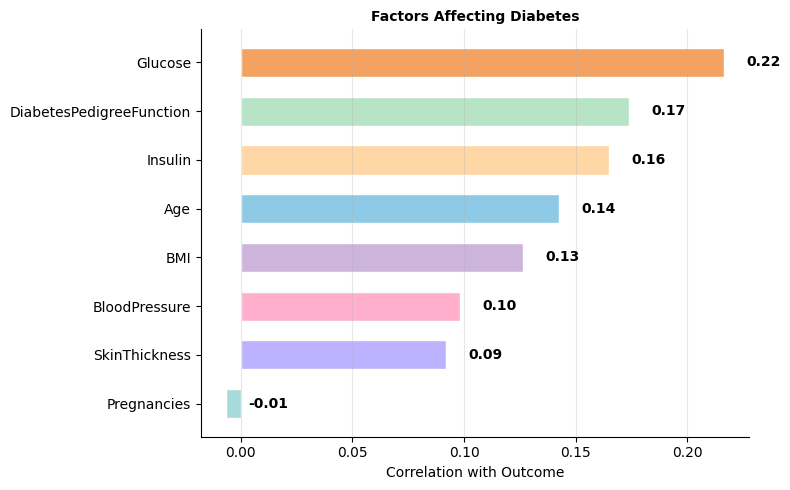

In [22]:
corr = numeric_df.corr()['Outcome'].drop('Outcome')
corr = corr.sort_values()
colors = ['#A8DADC', '#BDB2FF', '#FFAFCC','#CDB4DB', '#8ECAE6', '#FFD6A5','#B7E4C7', '#F4A261']
plt.figure(figsize=(8,5))
bars = plt.barh(corr.index,corr.values,color=colors[:len(corr)],edgecolor='white',height=0.6)
# value labels
for bar in bars:
    plt.text(bar.get_width() + 0.01,bar.get_y() + bar.get_height()/2,f'{bar.get_width():.2f}',
        va='center',fontsize=10,fontweight='bold')
plt.title("Factors Affecting Diabetes",fontsize=10,fontweight='bold')
plt.xlabel("Correlation with Outcome")
plt.grid(axis='x', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

In [23]:
# GLUCOSE DISTRIBUTION BY DIABETES OUTCOME

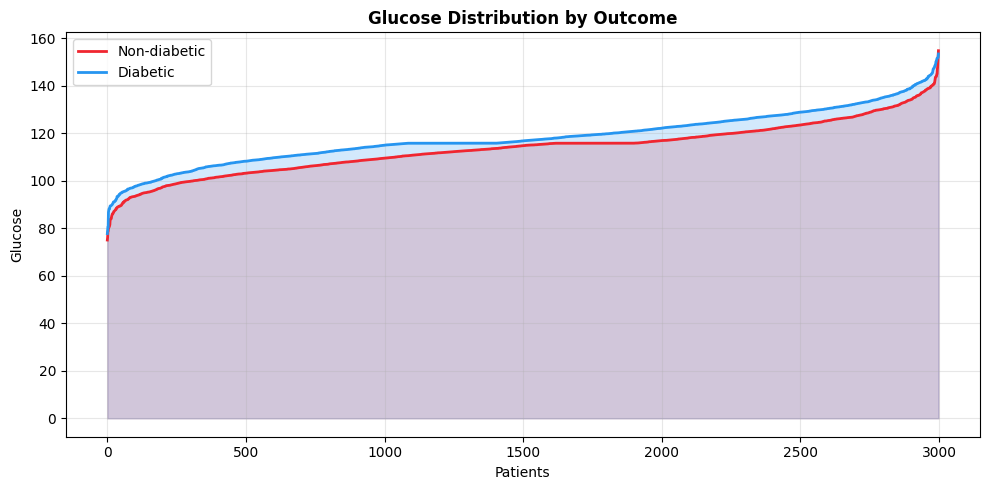

In [24]:
feature = 'Glucose'   
# Mean values by Outcome
non_diabetic = df[df['Outcome'] == 0][feature].sort_values().reset_index(drop=True)
diabetic = df[df['Outcome'] == 1][feature].sort_values().reset_index(drop=True)
# Make equal length
min_len = min(len(non_diabetic), len(diabetic))
non_diabetic = non_diabetic[:min_len]
diabetic = diabetic[:min_len]
x = range(min_len)
plt.figure(figsize=(10,5))
# Non-diabetic
plt.plot(x,non_diabetic,color='#F02630',linewidth=2,label='Non-diabetic')
plt.fill_between(x,non_diabetic,color='#F02630',alpha=0.2)
# Diabetic
plt.plot(x,diabetic,color='#2695F0',linewidth=2,label='Diabetic')
plt.fill_between(x,diabetic,color='#2695F0',alpha=0.2)
plt.title(f'{feature} Distribution by Outcome',fontsize=12,fontweight='bold')
plt.xlabel("Patients")
plt.ylabel(feature)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
#Glucose has the strongest effect on diabetes.
#Insulin, BMI, and Age also contribute to diabetes risk.
#BloodPressure and SkinThickness show weaker impact.
#Pregnancies show very little relationship with diabetes.
#Overall, Glucose is the most important diabetes-related factor in the dataset.


In [26]:
# RELATIONSHIP OF GLUCOSE WITH OTHER HEALTH FACTORS

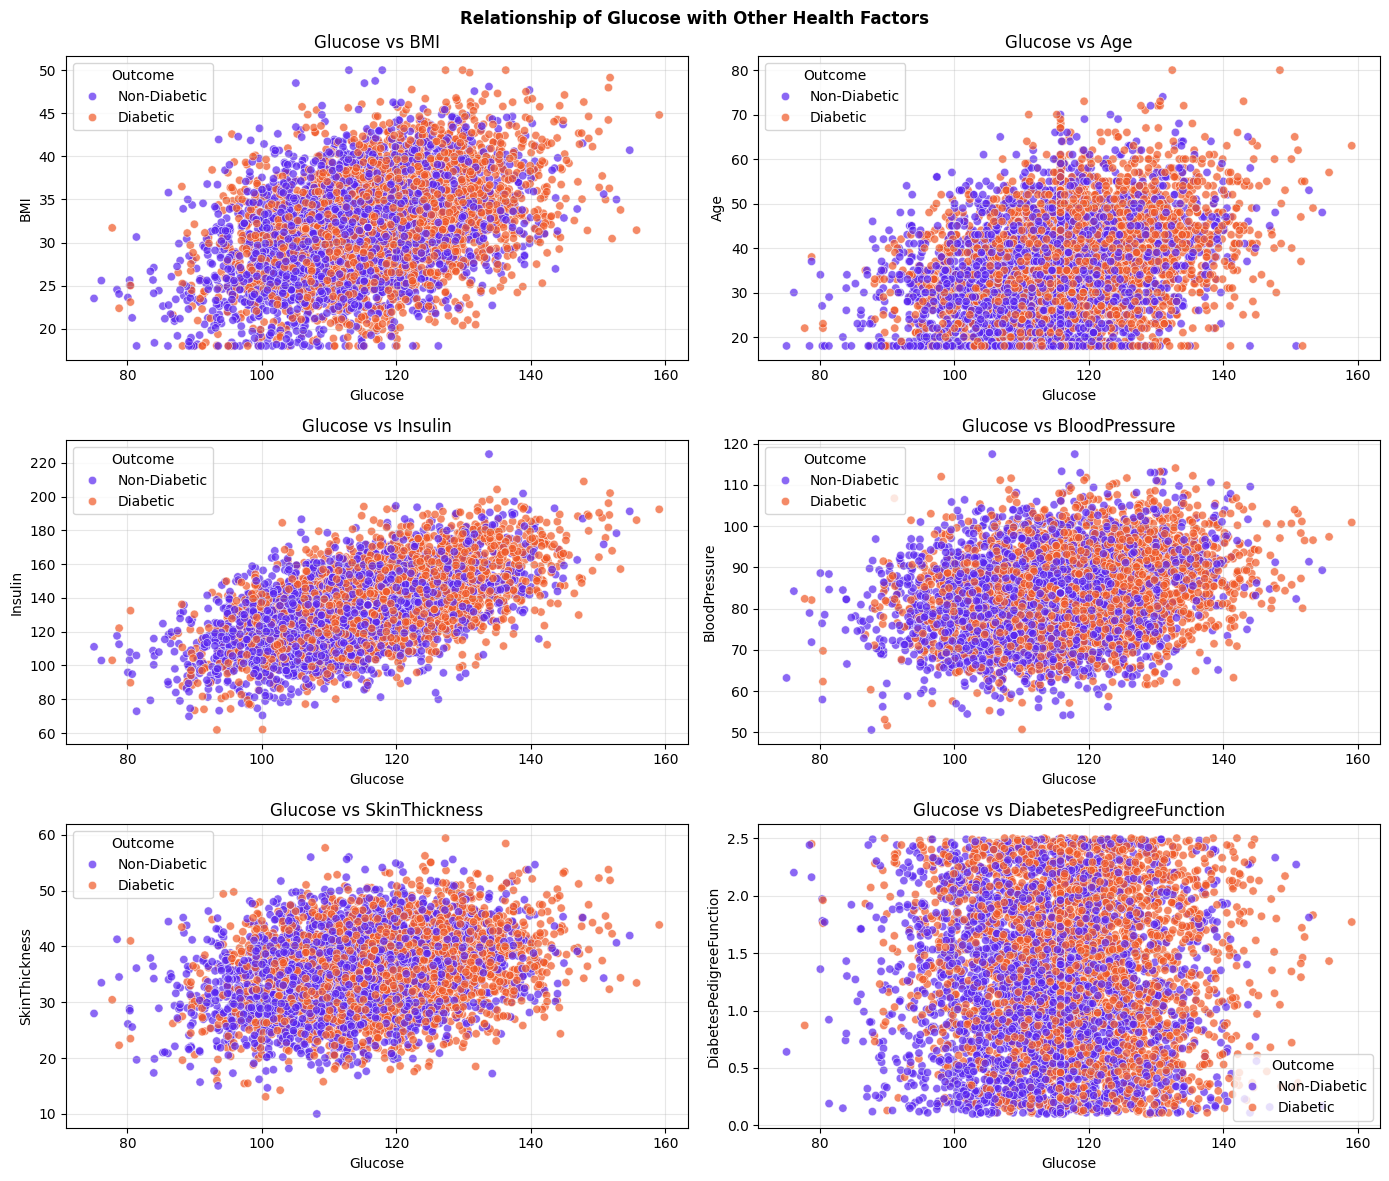

In [27]:
pairs = [('Glucose', 'BMI'),('Glucose', 'Age'), ('Glucose', 'Insulin'),('Glucose', 'BloodPressure'),
          ('Glucose', 'SkinThickness'),('Glucose', 'DiabetesPedigreeFunction')]
fig, ax = plt.subplots(3, 2, figsize=(14,12))
ax = ax.flatten()
for i, (x_col, y_col) in enumerate(pairs):
    sns.scatterplot(x=df[x_col], y=df[y_col],hue=df['Outcome'],palette=['#5826F0', '#F05826'],alpha=0.7,ax=ax[i])
    ax[i].set_title(f"{x_col} vs {y_col}")
    ax[i].grid(alpha=0.3)
    # Rename legend labels
    handles, labels = ax[i].get_legend_handles_labels()
    ax[i].legend(handles,['Non-Diabetic', 'Diabetic'],title='Outcome')
plt.suptitle("Relationship of Glucose with Other Health Factors",fontsize=12,fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# CONTRIBUTION OF BMI TO DIABETES RISK

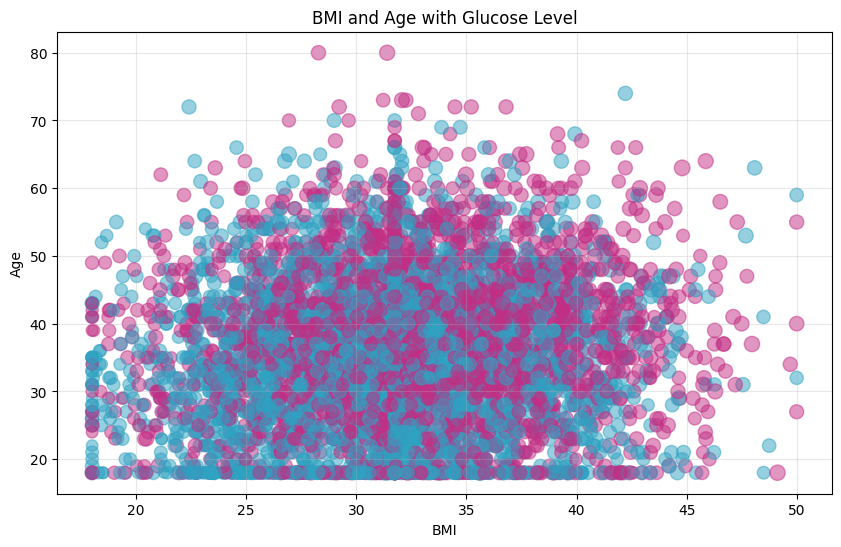

In [29]:
colors = df['Outcome'].map({0:'#2FA2C2',1:'#C22F85'})
plt.figure(figsize=(10,6))
plt.scatter( df['BMI'],df['Age'],s=df['Glucose'] * 0.8,c=colors,alpha=0.5)
plt.xlabel("BMI")
plt.ylabel("Age")
plt.title("BMI and Age with Glucose Level")
plt.grid(alpha=0.3)
plt.show()

In [30]:
# CONTRIBUTION OF INSULIN TO DIABETES RISK

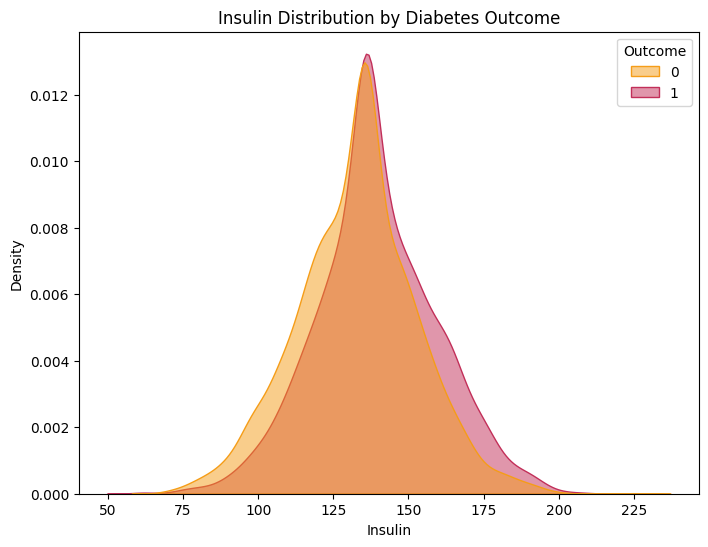

In [31]:
plt.figure(figsize=(8,6))
sns.kdeplot(data=df,x='Insulin',hue='Outcome',fill=True,palette=['#F59D18','#C22F59',],alpha=0.5)
plt.title("Insulin Distribution by Diabetes Outcome")
plt.xlabel("Insulin")
plt.ylabel("Density")
plt.show()

In [32]:
# AGE-BASED DIABETES RISK ANALYSIS

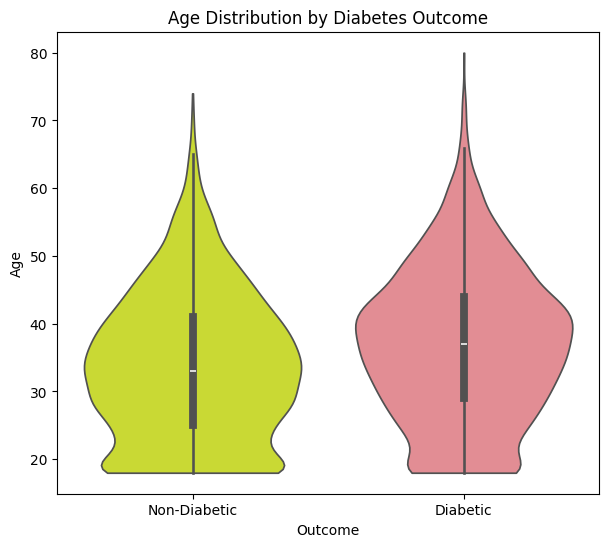

In [33]:
plt.figure(figsize=(7,6))
sns.violinplot(x='Outcome',y='Age',hue='Outcome',data=df,palette={0:'#DFF518', 1:'#F07F88'},inner='box',
                cut=0,legend=False)
plt.xticks([0,1], ['Non-Diabetic', 'Diabetic'])
plt.title("Age Distribution by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Age")
plt.show()

In [34]:
# ANALYSIS OF WEAKER DIABETES RISK FACTORS

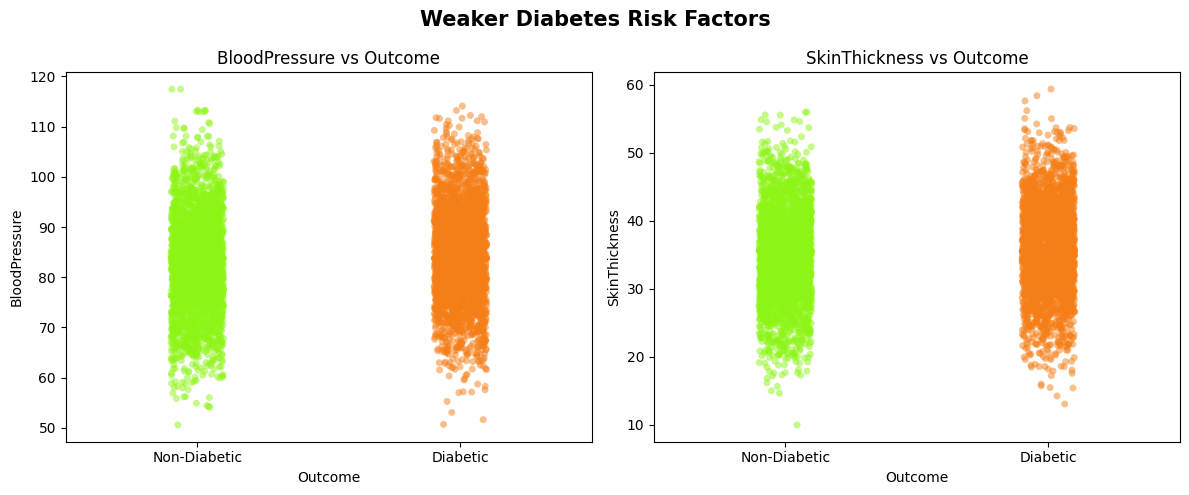

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))
# BloodPressure
sns.stripplot(x='Outcome', y='BloodPressure', hue='Outcome',data=df,palette={0:'#8DF516', 1:'#F57E16'},
              alpha=0.5,legend=False,ax=ax[0])
ax[0].set_title("BloodPressure vs Outcome")
ax[0].set_xticks([0,1])
ax[0].set_xticklabels(['Non-Diabetic', 'Diabetic'])
# SkinThickness
sns.stripplot(x='Outcome',y='SkinThickness',hue='Outcome',data=df,palette={0:'#8DF516', 1:'#F57E16'},
               alpha=0.5,legend=False,ax=ax[1])
ax[1].set_title("SkinThickness vs Outcome")
ax[1].set_xticks([0,1])
ax[1].set_xticklabels(['Non-Diabetic', 'Diabetic'])
plt.suptitle("Weaker Diabetes Risk Factors",fontsize=15,fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
# PREGNANCIES VS DIABETES ANALYSIS

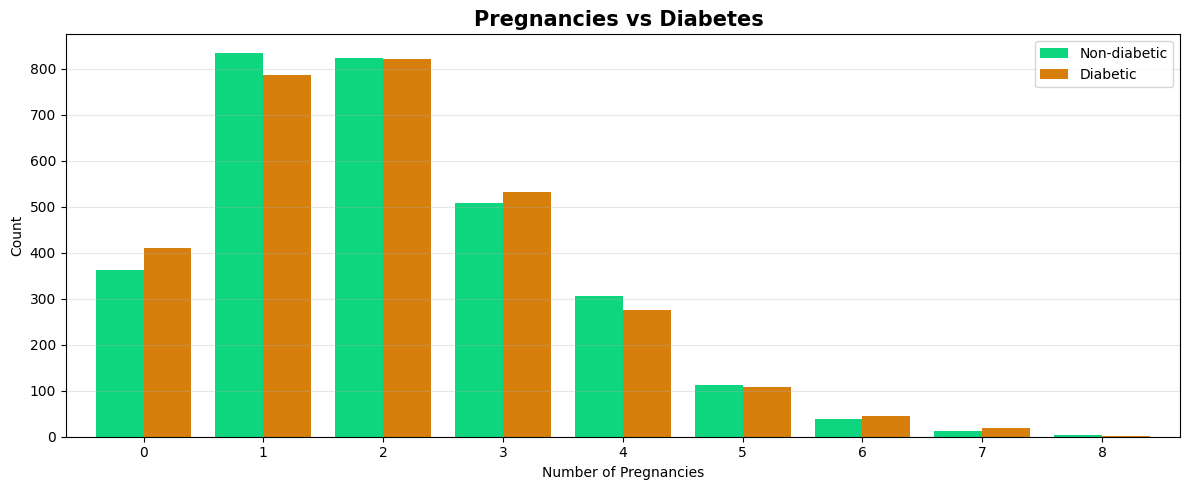

In [37]:
preg_data = df.groupby(['Pregnancies', 'Outcome']).size().unstack()
preg_data.plot(kind='bar',figsize=(12,5),color=['#0DD67F','#D67F0D'],width=0.8)
plt.title("Pregnancies vs Diabetes ",fontsize=15,fontweight='bold')
plt.xlabel("Number of Pregnancies")
plt.ylabel("Count")
plt.legend(['Non-diabetic', 'Diabetic'])
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
# CATEGORICAL ANALYSIS OF DIABETES RISK

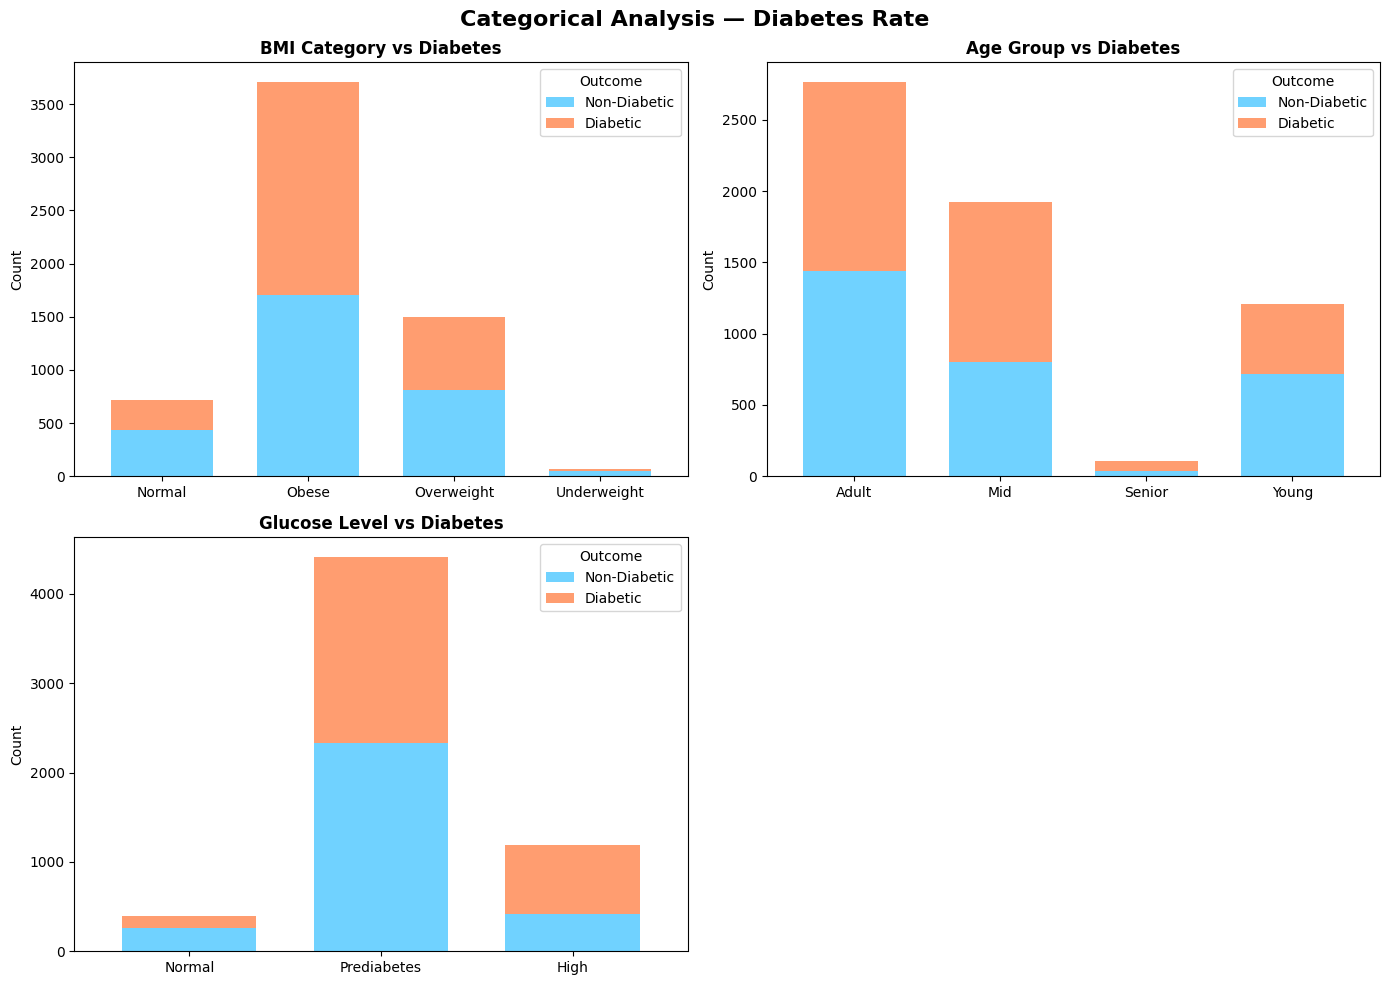

In [39]:
df['Glucose_Level'] = pd.cut(df['Glucose'],bins=[0, 99, 125, 200],
                             labels=['Normal', 'Prediabetes', 'High'])
fig, ax = plt.subplots(2, 2, figsize=(14,10))
bmi_data = df.groupby(['BMI_Category', 'Outcome']).size().unstack()
bmi_data.plot(kind='bar',stacked=True,color=['#70D2FF','#FF9D70'],ax=ax[0,0],width=0.7)
ax[0,0].set_title("BMI Category vs Diabetes", fontweight='bold')
ax[0,0].set_xlabel("")
ax[0,0].set_ylabel("Count")
ax[0,0].legend(['Non-Diabetic', 'Diabetic'], title='Outcome')
ax[0,0].tick_params(axis='x', rotation=0)
age_data = df.groupby(['Age_Group', 'Outcome']).size().unstack()
age_data.plot(kind='bar',stacked=True,color=['#70D2FF', '#FF9D70'],ax=ax[0,1],width=0.7)
ax[0,1].set_title("Age Group vs Diabetes", fontweight='bold')
ax[0,1].set_xlabel("")
ax[0,1].set_ylabel("Count")
ax[0,1].legend(['Non-Diabetic', 'Diabetic'], title='Outcome')
ax[0,1].tick_params(axis='x', rotation=0)
glucose_data = df.groupby(['Glucose_Level', 'Outcome'],observed=False).size().unstack()
glucose_data.plot( kind='bar',stacked=True,color=['#70D2FF', '#FF9D70'],ax=ax[1,0],width=0.7)
ax[1,0].set_title("Glucose Level vs Diabetes", fontweight='bold')
ax[1,0].set_xlabel("")
ax[1,0].set_ylabel("Count")
ax[1,0].legend(['Non-Diabetic', 'Diabetic'], title='Outcome')
ax[1,0].tick_params(axis='x', rotation=0)
fig.delaxes(ax[1,1])
plt.suptitle("Categorical Analysis — Diabetes Rate",fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
# COMBINED BMI AND AGE GROUP DIABETES ANALYSIS

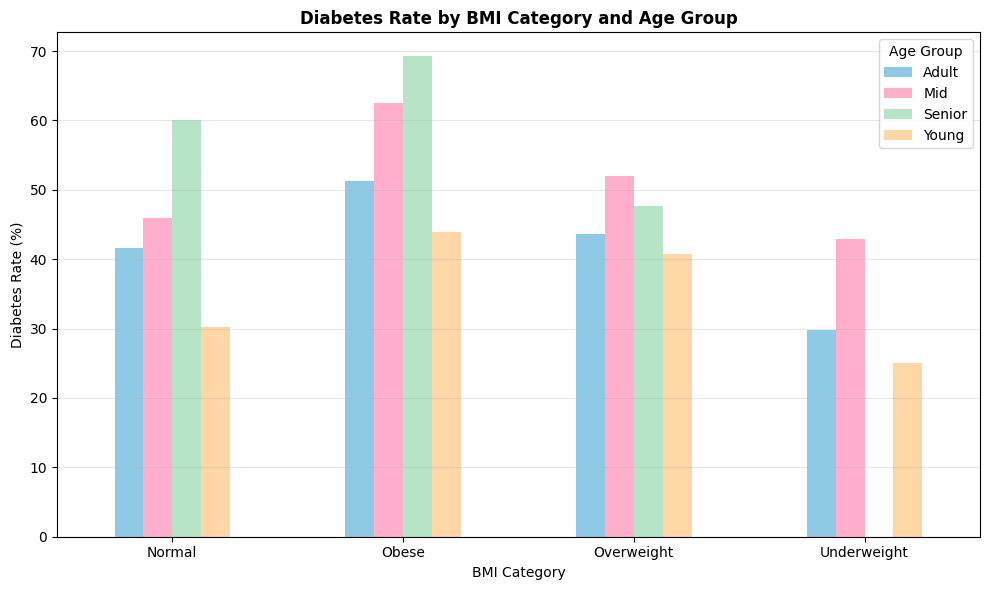

In [41]:
data = df.groupby(['BMI_Category', 'Age_Group'])['Outcome'].mean().unstack() * 100
data.plot(kind='bar',figsize=(10,6),color=['#8ECAE6', '#FFAFCC', '#B7E4C7', '#FFD6A5'])
plt.title("Diabetes Rate by BMI Category and Age Group", fontweight='bold')
plt.xlabel("BMI Category")
plt.ylabel("Diabetes Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Age Group")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
# CORRELATION HEATMAP OF DIABETES RISK FACTORS

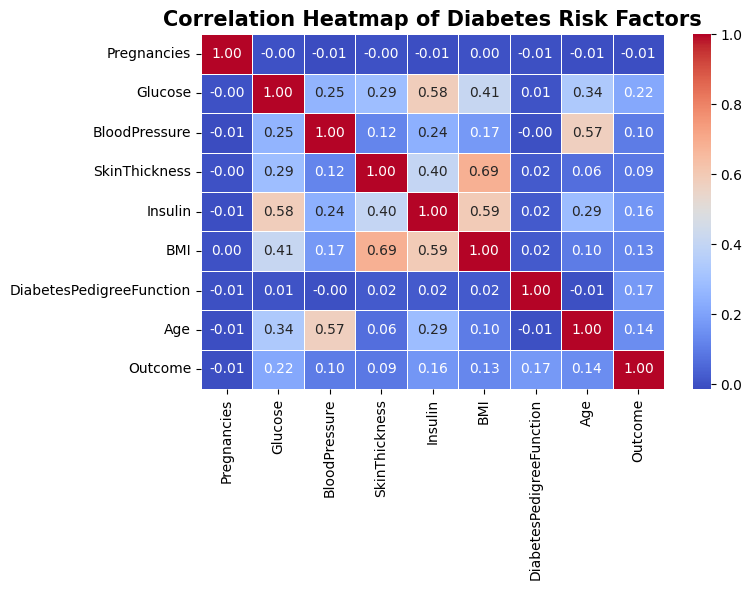

In [43]:
corr = numeric_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title("Correlation Heatmap of Diabetes Risk Factors",fontsize=15,fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# 🔥 KEEP ONLY ORIGINAL FEATURES
df = df[[
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]]

# SPLIT
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# MODEL (YOUR BEST ONE)
model = RandomForestClassifier(
    n_estimators=150, 
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# RESULT
print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))

Accuracy: 0.5958333333333333


In [45]:
# ==============================
# 10. SAVE MODEL
# ==============================
pickle.dump(model, open("diabetes_model.pkl", "wb"))
pickle.dump(X_train.columns.tolist(), open("columns.pkl", "wb"))

print("\n🔥 Final Random Forest model saved!")


🔥 Final Random Forest model saved!
